In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.filters.hp_filter import hpfilter
import os

## Exercise 13.3 (mandatory assignment 1)

### 13.3.1

#### Apply HP Filter with $\lambda=1600$ to data series for GDP, private consumption and private investment.

In [ ]:
def apply_hp_filter(data, series_name, lambda_param=100):
    """
    Apply natural log transformation and Hodrick-Prescott filter to economic data.
    
    Parameters:
    -----------
    data : pandas.Series
        GDP, consumption and investment data series with years as index.
    country_name : str
        Name of the series for labeling.
    lambda_param : int
        Smoothing parameter for HP filter.
        
    Returns:
    --------
    tuple
        (cycle, trend) components from HP filter.
    """
    # Apply natural log transformation.
    log_data = np.log(data)
    
    # Apply HP filter to the log-transformed data.
    cycle, trend = hpfilter(log_data, lamb=lambda_param)
    
    # Create a figure with two subplots.
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))
    
    # Plot original log data and trend.
    ax1.plot(log_data.index, log_data, 'b-', label=f'Log {series_name}')
    ax1.plot(trend.index, trend, 'r-', label='Trend Component')
    ax1.set_title(f'Log {series_name} and Trend Component')
    ax1.set_xlabel('Year')
    ax1.set_ylabel(f'Log {series_name}')
    ax1.legend()
    ax1.grid(True)
    
    # Plot cyclical component (output gap).
    ax2.plot(cycle.index, 100*cycle, 'g-') # Multiply by 100 for percentage.
    ax2.set_title(f'{series_name} Cyclical Component')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Pct. Deviation from Trend')
    ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{series_name}_hp_filter_log.png')  # Save figure for reference.
    plt.show()  # Show the plot directly.
    
    return cycle, trend

In [3]:
# Read data. 
file_path = "Ex_13.3_dataset.xlsx"
sheet = "Sheet1"
skiprows = 10
nrows = 233

# Dataframes. 
quarters_df = pd.read_excel(file_path, sheet_name=sheet, usecols="A", skiprows=skiprows, 
                            header=None, names=["Quarter from"], nrows=nrows, parse_dates=True)
gdp_df = pd.read_excel(file_path, sheet_name=sheet, usecols="B", skiprows=skiprows, 
                       header=None, names=["GDP"], nrows=nrows)
pconsmpt_df = pd.read_excel(file_path, sheet_name=sheet, usecols="C", skiprows=skiprows, 
                            header=None, names=["Private Consumption"], nrows=nrows)
pinvest_df = pd.read_excel(file_path, sheet_name=sheet, usecols="D", skiprows=skiprows, 
                           header=None, names=["Private Investment"], nrows=nrows)
# Combine dataframes.
denmark_df = pd.concat([quarters_df, gdp_df, pconsmpt_df, pinvest_df], axis=1)

denmark_df.set_index("Quarter from", inplace=True)

In [4]:
denmark_df.head()

,GDP,Private Consumption,Private Investment
Quarter from,,,
1966-01-01,6.874472e+11,3.616644e+11,1.100992e+11
1966-04-01,6.975865e+11,3.701898e+11,1.137674e+11
1966-07-01,7.074260e+11,3.770426e+11,1.165040e+11
1966-10-01,7.169870e+11,3.824790e+11,1.184783e+11
1967-01-01,7.269567e+11,3.929450e+11,1.228105e+11


In [5]:
print(f"Data from {denmark_df.index.min()} to {denmark_df.index.max()}")
print(f"Number of quarters = {len(denmark_df)}")
print(f"Number of years = {len(denmark_df)/4}")
print("\n Statistics:")
print(denmark_df.describe())

Data from 1966-01-01 00:00:00 to 2021-07-01 00:00:00
Number of quarters = 223
Number of years = 55.75

 Statistics:
                GDP  Private Consumption  Private Investment
count  2.230000e+02         2.230000e+02        2.230000e+02
mean   1.424183e+12         6.852422e+11        2.648648e+11
std    4.229514e+11         1.747893e+11        1.057230e+11
min    6.874472e+11         3.616644e+11        1.100992e+11
25%    1.045295e+12         5.396190e+11        1.712853e+11
50%    1.359620e+12         6.578268e+11        2.266996e+11
75%    1.824583e+12         8.591907e+11        3.406088e+11
max    2.228845e+12         1.017144e+12        5.189241e+11


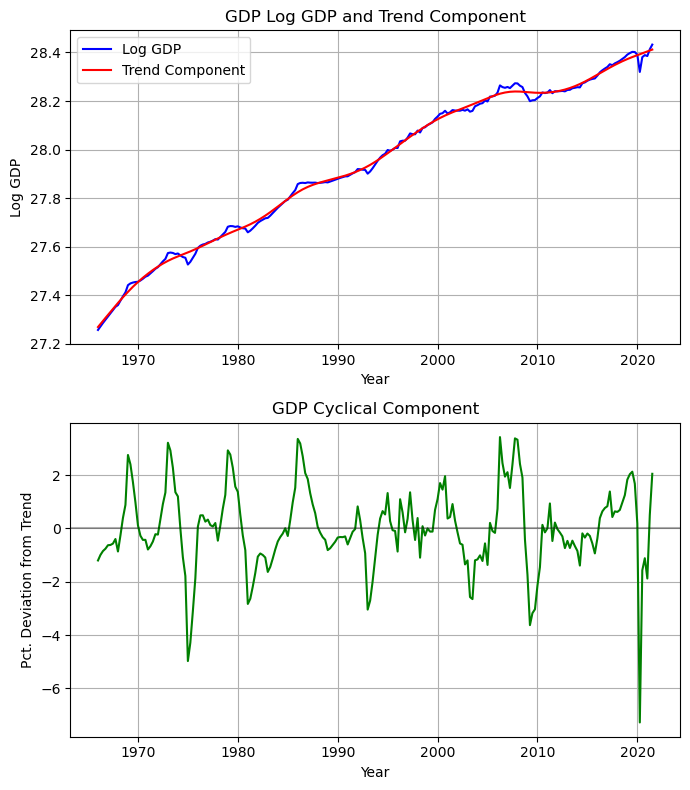

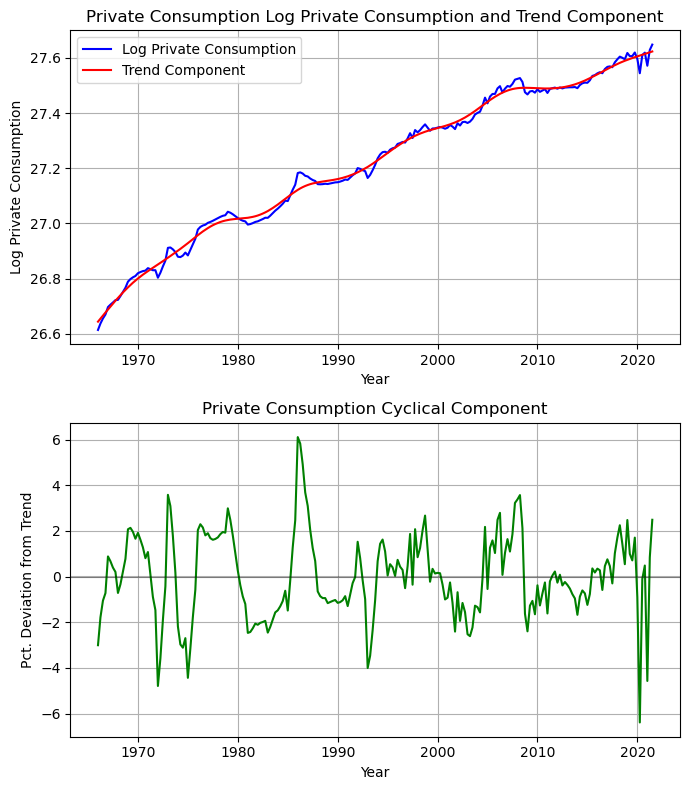

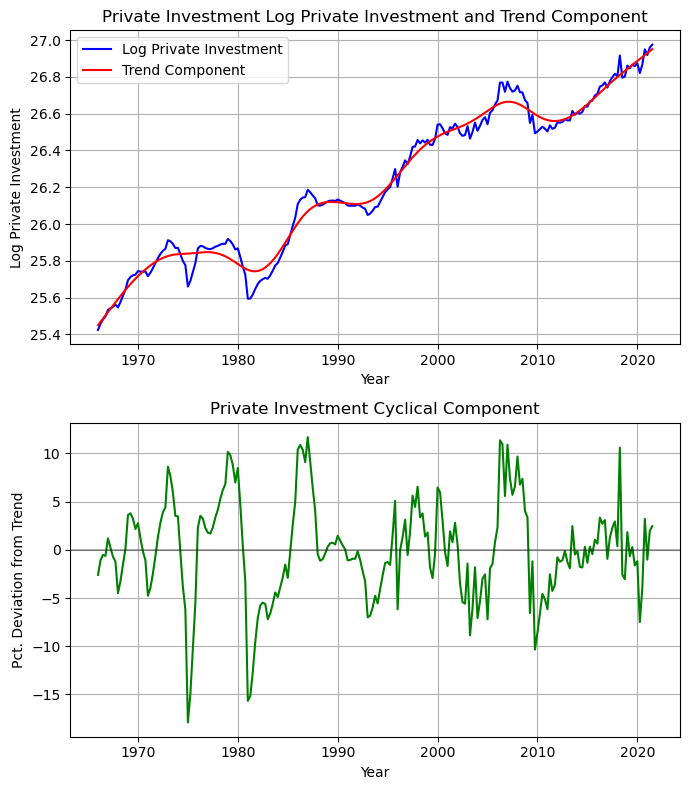

In [6]:
trend_results = {}
l = 1600 # Lambda parameter.
series = ["GDP", "Private Consumption", "Private Investment"]

for s in series: 
    cycle, trend = apply_hp_filter(denmark_df[s], s, lambda_param=l)

    denmark_series_df = pd.DataFrame({
        "original_GDP": denmark_df["GDP"],
        "log_GDP": np.log(denmark_df["GDP"]),
        "p_consumption": denmark_df["Private Consumption"],
        "log_p_consumption": np.log(denmark_df["Private Consumption"]),
        "p_investment": np.log(denmark_df["Private Investment"]),
        "trend": trend, 
        "cycle": cycle, 
        "pct. cycle": cycle * 100
    })